### Анализ стартапа (Маркетплейса) с товарами из Бразилии

#### Описание данных

##### olist_customers_dataset.csv — таблица с уникальными идентификаторами пользователей
customer_id — позаказный идентификатор пользователя

 - customer_unique_id — уникальный идентификатор пользователя (аналог номера паспорта)
 - customer_zip_code_prefix — почтовый индекс пользователя
 - customer_city — город доставки пользователя
 - customer_state — штат доставки пользователя

-------

##### olist_orders_dataset.csv —  таблица заказов

 - order_id — уникальный идентификатор заказа (номер чека)
 - customer_id — позаказный идентификатор пользователя
 - order_status — статус заказа
 - order_purchase_timestamp — время создания заказа
 - order_approved_at — время подтверждения оплаты заказа
 - order_delivered_carrier_date — время передачи заказа в логистическую службу
 - order_delivered_customer_date — время доставки заказа
 - order_estimated_delivery_date — обещанная дата доставки

-------

##### olist_order_items_dataset.csv — товарные позиции, входящие в заказы
 - order_id — уникальный идентификатор заказа (номер чека)
 - order_item_id — идентификатор товара внутри одного заказа
 - product_id — ид товара (аналог штрихкода)
 - seller_id — ид производителя товара
 - shipping_limit_date — максимальная дата доставки продавцом для передачи заказа партнеру по логистике
 - price — цена за единицу товара
 - freight_value — вес товара 

In [2]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

**Читаем данные**

In [3]:
# Пользователи
users = pd.read_csv('olist_customers_dataset.csv')

In [4]:
users.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [5]:
# Заказы
orders = pd.read_csv('olist_orders_dataset.csv')

In [6]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [7]:
# Товарные позиции, входящие в заказы
items = pd.read_csv('olist_order_items_dataset.csv')

In [8]:
items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


#### Проверка и преобразование данных

In [9]:
# Пользователи

In [10]:
users.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [11]:
# Заказы

In [12]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [13]:
orders.shape

(99441, 8)

In [14]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders.order_purchase_timestamp)
orders['order_approved_at'] = pd.to_datetime(orders.order_approved_at)
orders['order_delivered_carrier_date'] = pd.to_datetime(orders.order_delivered_carrier_date)
orders['order_delivered_customer_date'] = pd.to_datetime(orders.order_delivered_customer_date)
orders['order_estimated_delivery_date'] = pd.to_datetime(orders.order_estimated_delivery_date)

In [15]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [16]:
# Товары

In [17]:
items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [18]:
items['shipping_limit_date'] = pd.to_datetime(items.shipping_limit_date)

In [19]:
items.dtypes

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object

**Оценим месячный retention в оформление заказа с помощью когортного анализа.**

In [20]:
ord_copy = orders[['customer_id', 'order_purchase_timestamp']].copy()

In [21]:
ord_copy = ord_copy.merge(users[['customer_id', 'customer_unique_id']], how='inner', on='customer_id')

In [22]:
ord_copy.drop('customer_id', axis=1, inplace=True)

In [23]:
ord_copy.head(3)

,order_purchase_timestamp,customer_unique_id
0,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff
1,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231
2,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8


**Считаем Retention**

In [24]:
# Retention строим по оформленным заказам

In [25]:
ord_copy['order_period'] = ord_copy.order_purchase_timestamp.dt.to_period('M')

In [26]:
ord_copy['cohort'] = ord_copy.groupby('customer_unique_id')['order_period'].transform('min')

In [27]:
ord_copy['period_number_month'] = (ord_copy['order_period'] - ord_copy['cohort']).apply(lambda x: x.n)

In [28]:
df_cohort = ord_copy.groupby(['cohort', 'period_number_month']).agg({'customer_unique_id': 'nunique'}).reset_index()

In [29]:
df_cohort.head(3)

,cohort,period_number_month,customer_unique_id
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1


In [30]:
pivot_df = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='customer_unique_id')

In [31]:
pivot_df

period_number_month,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [32]:
# переводим в доли

In [33]:
size = pivot_df.iloc[:, 0]

In [34]:
retention = pivot_df.divide(size, axis=0)

**медианный retention 1-го месяца в долях**

In [35]:
retention.iloc[:, 1].median()

0.005005561735261402

**Найдем когорту с самым высоким retention на 3-й месяц.**

In [36]:
retention.iloc[:, 3].idxmax()

Period('2017-06', 'M')

In [37]:
# Доля в данной когорте
retention.loc['2017-06', 3]

np.float64(0.00414144632048423)

**Визуализация когортного анализа**

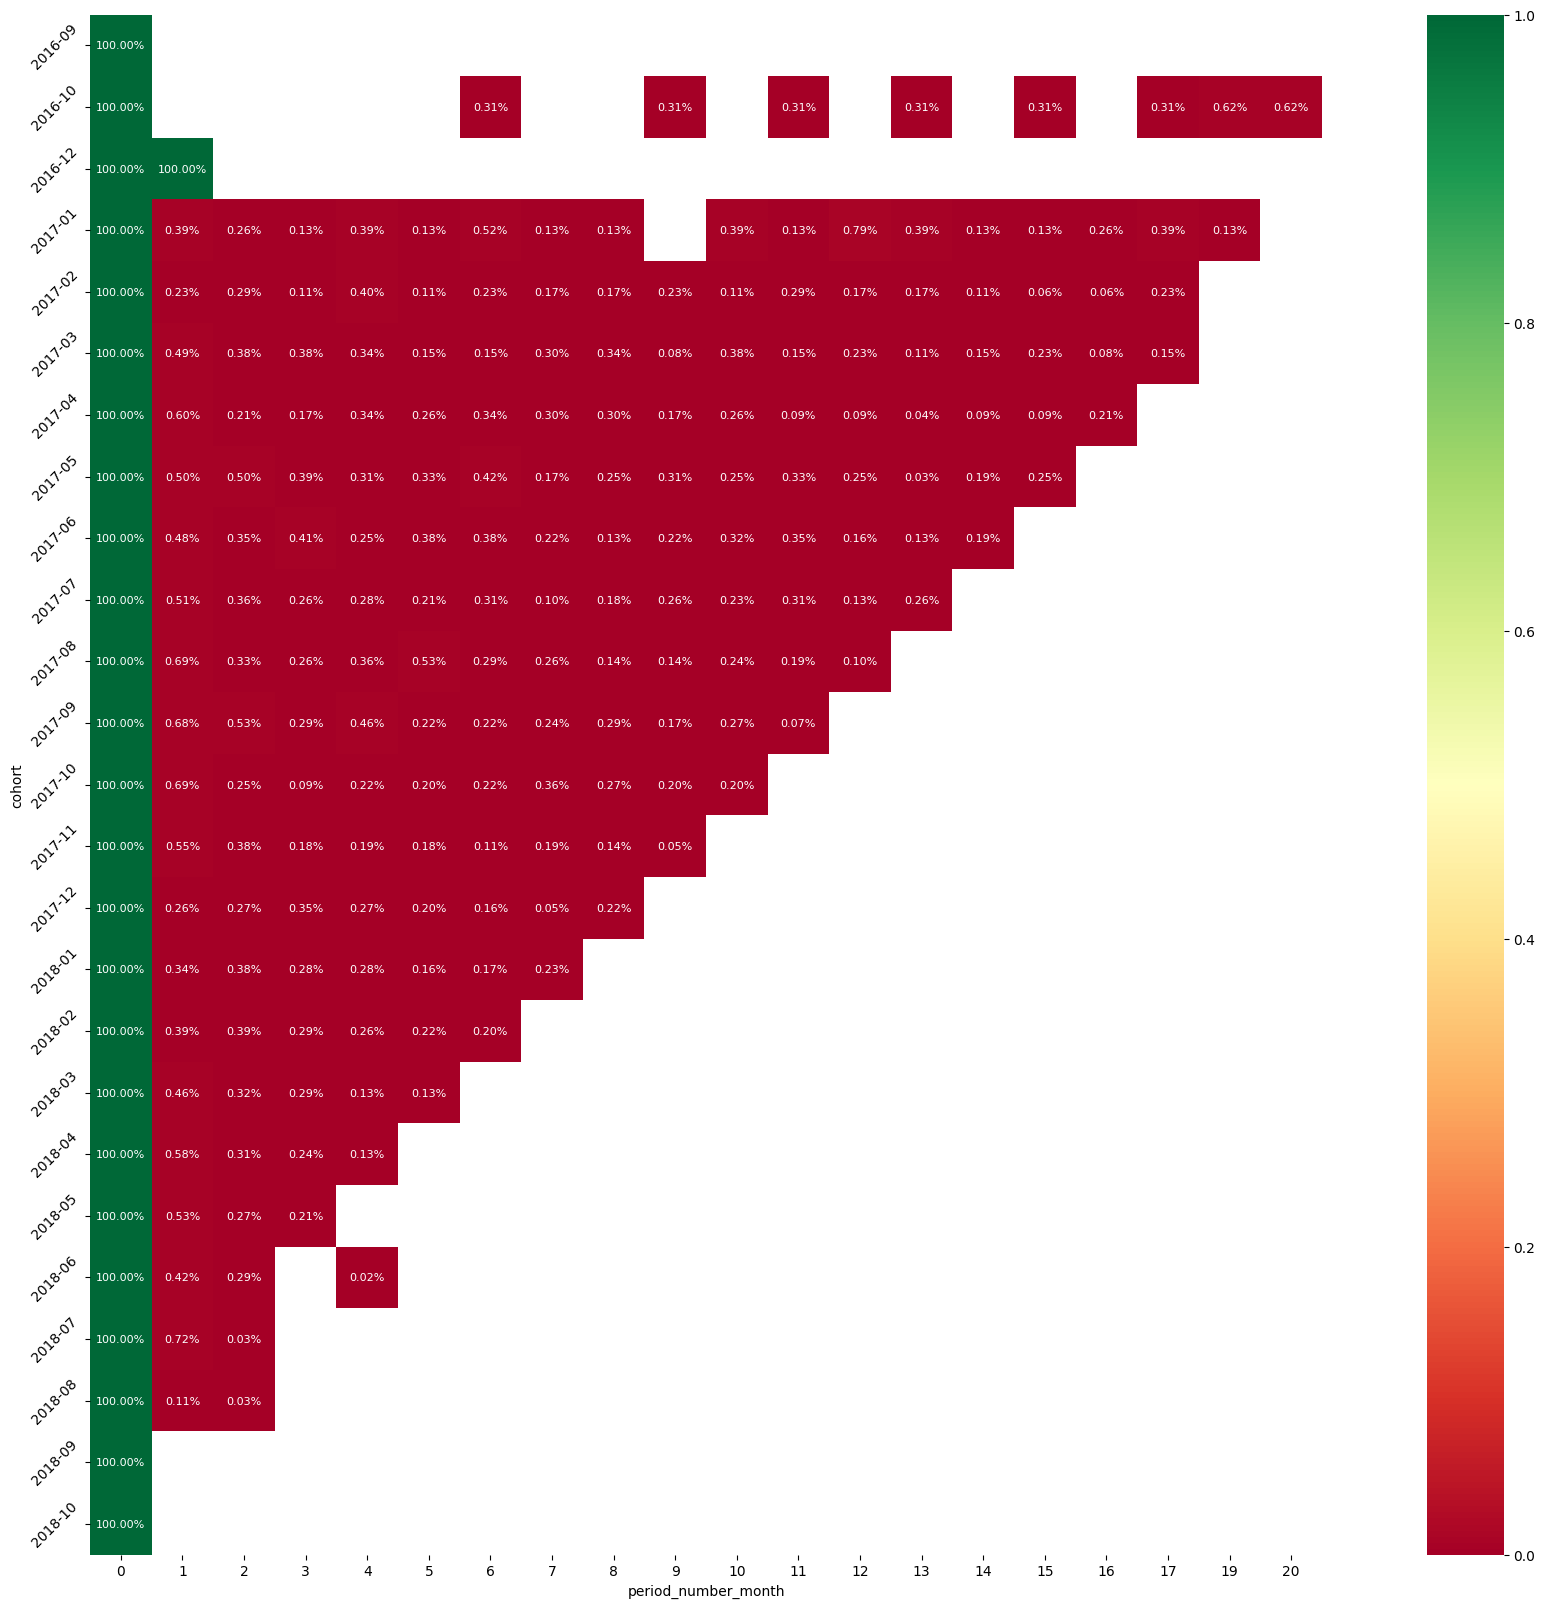

In [38]:
plt.figure(figsize=(27, 20))
sns.heatmap(
    retention,
    annot=True,          
    fmt='.2%',          
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    annot_kws={"size": 8},
    square=True
)
plt.yticks(rotation=45)
plt.savefig('retention.png', bbox_inches='tight', dpi=100)

<span style='font-size: 20px'>Вывод о Retention<span/>

Анализ расчета retention по когортам показал низкий уровень удержания клиентов.\
Уже на первом месяце retention составляет менее 1%.\
Отсутствует стабильность и выход на плато.\
Пользователи уходят после первой покупки, что говорит
о недостаточной ценности продукта. \
И указывает на возможное отсутствие product/market fit.

**Проверим существует ли у продукта PMF и точки роста?**

Мы заметили что в нашем маркетплейсе низкая возращаемость после 1 покукпи, \
что уже указывает на очень слабый PMF, и с большей вероятностью всего на его отстутвие. \
Посмотрим, какой процент пользователй делает больше одного, двух, трех заказа?

In [39]:
more_1 = sum(ord_copy.groupby('customer_unique_id')['order_purchase_timestamp'].count() > 1) / len(ord_copy)
more_2 = sum(ord_copy.groupby('customer_unique_id')['order_purchase_timestamp'].count() > 2) / len(ord_copy)
more_3 = sum(ord_copy.groupby('customer_unique_id')['order_purchase_timestamp'].count() > 3) / len(ord_copy)

In [40]:
print(f"""
Процент пользователей которые сделали повторный заказ составляет: {more_1:.2%}
Процент пользователей которые сделали более двух заказов составляет: {more_2:.2%}
Процент пользователей которые сделали более трех заказов составляет: {more_3:.2%}
""")


Процент пользователей которые сделали повторный заказ составляет: 3.01%
Процент пользователей которые сделали более двух заказов составляет: 0.25%
Процент пользователей которые сделали более трех заказов составляет: 0.05%



Начнем поиск причино следсвенной связи отстутвия PMF \
Возможно у макреплейста долгая доставка

In [41]:
diff_time = (orders.order_estimated_delivery_date - orders.order_delivered_customer_date).dt.days

In [42]:
# Процент заказов доставленных в назначенный день
sum(diff_time < 1) / len(diff_time) * 100

9.341217405295604

In [43]:
# Процент заказов доставленных раньше
sum(diff_time < 0)

7827

In [44]:
print(diff_time.mean())
print(diff_time.median())

10.876881296902857
11.0


In [45]:
# Процент заказов доставленных позже обещанной даты
sum(diff_time > 0) / len(diff_time) * 100

87.67711507325953

Доставка в среднем задерживается на 11 дней, что может быть одним из признаков низкого retention \
Клиенты не готовы повторно делать заказ и снова долго ждать

In [46]:
# время подтверждения оплаты заказа
((orders.order_approved_at - orders.order_purchase_timestamp).dt.days).mean()

np.float64(0.2697998610005943)

In [47]:
(orders.order_delivered_carrier_date - orders.order_approved_at).mean()

Timedelta('2 days 19:19:15.298850927')

In [48]:
# Сколько времени в среднем требуется продавцам на отправку

In [49]:
df = items[['order_id', 'shipping_limit_date']] \
    .merge(orders[['order_id', 'order_approved_at']], how='inner', on='order_id')

In [50]:
((df.shipping_limit_date - df.order_approved_at).dt.days).mean()

np.float64(6.020739556976073)

In [51]:
# помотерть количсевто отмен


In [52]:
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<span style='font-size: 20px'>Вывод о PMF<span/>

У маркетплейса наблюдаются проблемы с доставкой, в среднем клиент ждет свой товар \
на 11 дней дольше чем время обещанной доставки. \
В следствие чего 93% пользователей не делают повторный заказ. \
Можем сделать вывод, что у макретплейса отсутсвует product/market fit.

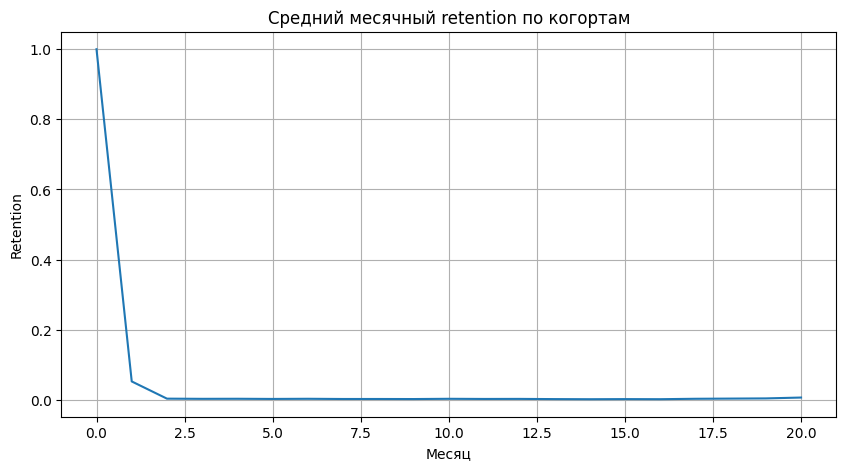

In [53]:
plt.figure(figsize=(10, 5))     
retention.mean().plot()

plt.title('Средний месячный retention по когортам')
plt.xlabel('Месяц')
plt.ylabel('Retention')
plt.grid(True)

**Определим 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.** \
 1. Выручка (GMV) –– будет отражает рост объёма продаж маркетплейса

 2. Количество активных пользователей которые сделали заказ (например за каждый месяц) –– данная метрика показывает объем аудитории, которой продукт доставляет ценность.

 3. Конверсия в заказ из корзины –– отражает заинтересованность новых клиентов в продукте

 4. Retention (доля пользователей совершивших повторный заказ) –– отражает вовлеченность клиента в продолжение использования продукта.

 5. ARPPU –– отражает денежное выражение вовлеченности клиента.


**Посмотрим метрики на графиках**

<span style='font-size: 16px'>Выручка<span/>

In [54]:
rev = items.merge(orders, how='inner', on='order_id') \
    .query("order_status == 'delivered'") \
    .set_index('order_approved_at') \
    .resample('ME')['price'].sum()

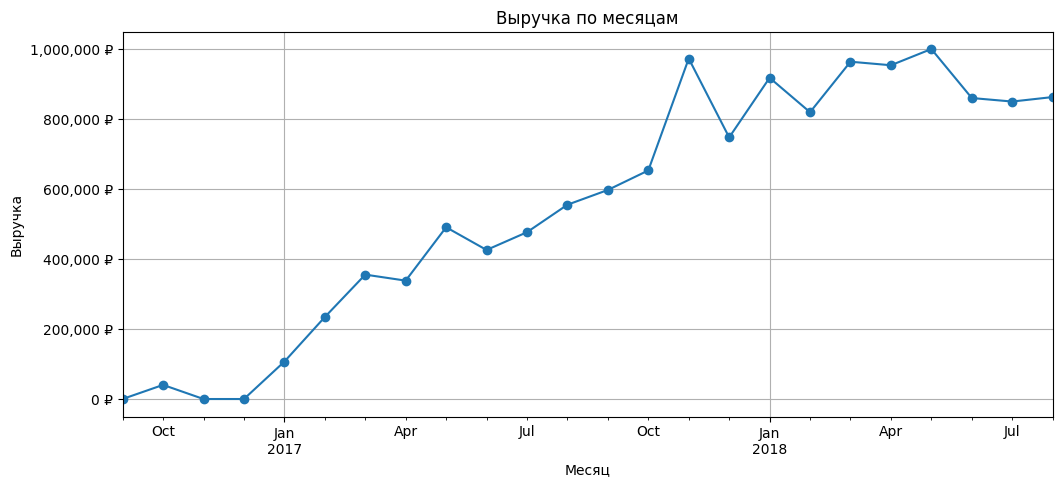

In [55]:
ax = rev.plot(figsize=(12, 5), marker='o')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x:,.0f} ₽'))

<span style='font-size: 16px'>Количество активных пользователей которые сделали заказ<span/>

In [56]:
active_users = orders \
    .set_index('order_approved_at') \
    .resample('ME')['customer_id'].nunique()

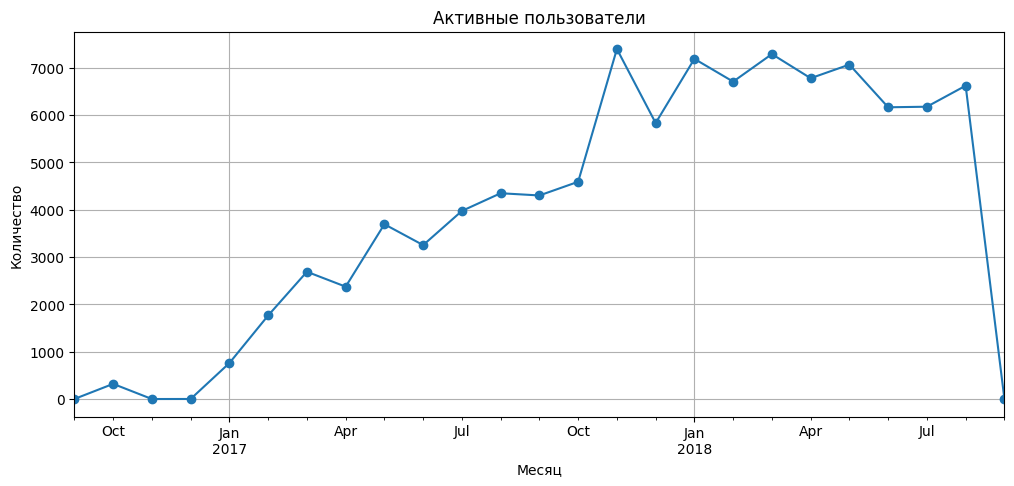

In [57]:
active_users.plot(figsize=(12, 5), marker='o')
plt.title('Активные пользователи')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.grid()

<span style='font-size: 16px'>Retention<span/>

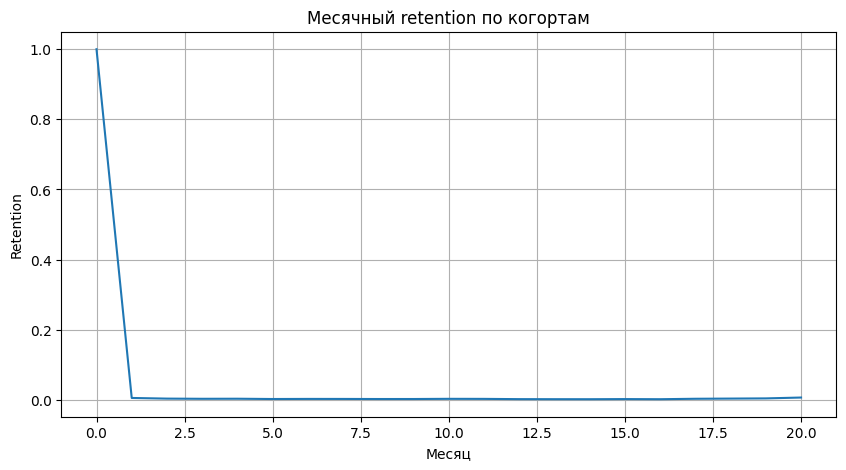

In [58]:
plt.figure(figsize=(10, 5))     
retention.median().plot()

plt.title('Месячный retention по когортам')
plt.xlabel('Месяц')
plt.ylabel('Retention')
plt.grid(True)

<span style='font-size: 16px'>ARPPU<span/>

In [59]:
data = items.merge(orders, how='inner', on='order_id') \
    .query("order_status == 'delivered'")

In [60]:
arppu = round(data['price'].sum() / data['customer_id'].nunique(), 2)
print(f"ARRPU за все время составляет –– {arppu}₽")

ARRPU за все время составляет –– 137.04₽


In [61]:
data['order_approved_at'] = data['order_approved_at'].dt.to_period('M')

In [62]:
sum_by_month = data.groupby('order_approved_at').agg({'price': 'sum', 'customer_id': 'nunique'})

In [63]:
arrpu_by_month = sum_by_month.price / sum_by_month.customer_id

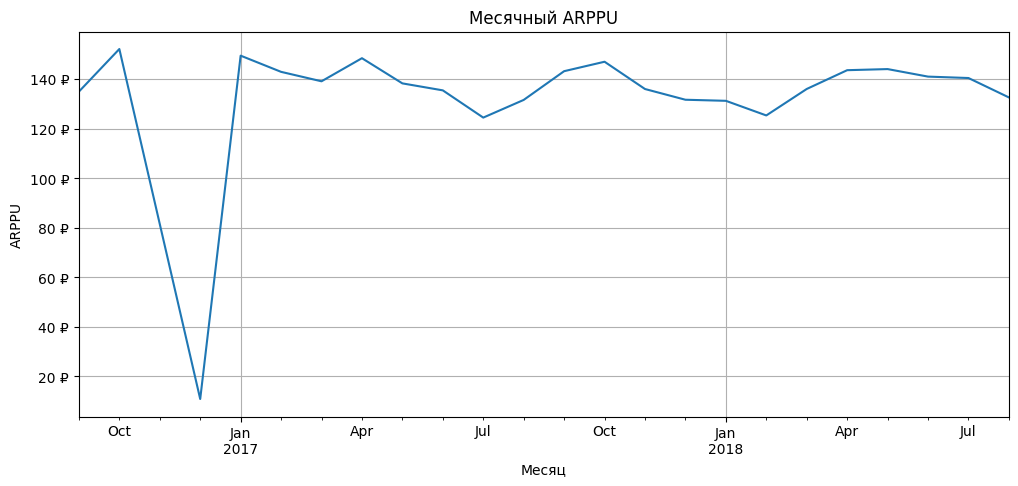

In [64]:
ax = arrpu_by_month.plot(figsize=(12, 5))
plt.title('Месячный ARPPU')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.grid()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x)} ₽'))

**Выбираем одну из 3 основных гипотез с помощью фреймворка ICE.**

 1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

 2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.

 3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.

In [65]:
# Будем оценить влияние на продукт по метрике коверсия в повторный заказ (Retention за 1 месяц)

In [66]:
ret_1_month = round(retention.median(axis=0)[1], 4)

In [67]:
ret_1_month

np.float64(0.005)

**Первая гипотеза**

Проблема отмены заказа

Если решить проблему отмены заказов, то сколько пользователей сделают потворный заказ

In [68]:
# Оставляем заказы только с июня 2017
df_2017 = orders[orders['order_purchase_timestamp'] >= '2017-06-01'].copy()

In [78]:
res = df_2017[(df_2017['order_status'] == 'canceled') | (df_2017['order_status'] == 'unavailable')]
impact_1 = res.shape[0] * ret_1_month

In [79]:
impact_1

np.float64(4.87)

Важность первой гипотезы по шкале impact равна 1

**Вторая гипотеза**

In [71]:
df_2017['is_late'] = (df_2017['order_delivered_customer_date'] - df_2017['order_estimated_delivery_date']).dt.days > 0

In [72]:
late = df_2017[df_2017['is_late']]

In [1]:
res2 = late.merge(users[['customer_unique_id', 'customer_id']], how='inner', on='customer_id')
impact_2 = res2['customer_unique_id'].nunique() * ret_1_month

NameError: name 'late' is not defined

In [74]:
impact_2

np.float64(30.275000000000002)

Важность второй гипотезы по шкале impact равна 1

**Третья гипотеза**

In [75]:
df = users[['customer_unique_id', 'customer_id']].merge(df_2017[['order_id', 'customer_id']], on='customer_id')

In [76]:
order_1 = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()['order_id'] == 1

In [77]:
order_1.shape[0] * ret_1_month

np.float64(425.095)

Важность третьей гипотезы по шкале impact равна 4

Таблица ICE

<table>
  <thead>
    <tr>
      <th>Гипотеза</th>
      <th >Impact</th>
      <th >Confidence</th>
      <th >Ease</th>
      <th >ICE</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>1. Исправление багов процессинга</td>
      <td >1</td>
      <td >8</td>
      <td >6</td>
      <td >48</td>
    </tr>
    <tr>
      <td>2. Сокращение времени отгрузки</td>
      <td >1</td>
      <td >10</td>
      <td >4</td>
      <td >40</td>
    </tr>
    <tr>
      <td>3. Новый способ оплаты</td>
      <td >4</td>
      <td >5</td>
      <td >9</td>
      <td >180</td>
    </tr>
  </tbody>
</table>

Метрики на которые повлияет наша гипотеза

Целевая метрика - Конверсия в повторный заказ \
Proxy метрика - Конверсия в заказ из корзины \
guardrail метрика - Доля ошибок при заказе (Количество неуспешных попыток отплаты / Количество всех попыток оплаты) * 100

### Финальный отчет

Главная проблема продукта — низкое удержание клиентов. Исследование показало, что медианный Retention 1-го месяца составляем менее 1%. Это означает, что 99% покупателей уходят после первого заказа. Именно это является причиной, по которой выручка маркетплейса стоит на месте. Мы тратим ресурсы на привлечение новых пользователей, но не можем сформировать базу лояльных клиентов, которые приносили бы стабильный доход.

---------

В результате исследования:

 - мы выяснили что у продукта низкий Retention и в следствии отстутвие Product/Market Fit
 - определили 5 основных метрик эффективности продукта (GMV, Active Users, CR, Retention, ARPPU)
 - через фреймворк ICE выбрали приоритетную гипотезу - добавить новый способ оплаты. Это может повлиять на большое количество пользователей и дать им повод вернуться.
 - сформулировали основные метрики перед проведением АБ тестирования:
   1. Целевая метрика - Конверсия в повторный заказ
   2. Proxy метрика - Конверсия в заказ из корзины
   3. Guardrail метрика - Доля ошибок при заказе

----------

Рекомендации по продукту
 - Внедрить новый способ оплаты. Провести АБ тестирование. Чтобы понять, решаем ли мы проблему пользователей.
 - Ускорить время доставки. Или же давать клиентам честный прогноз. В противном случае пользователь может уйти из макреплейса.